In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('adult_data.csv')
df.columns = ['age','workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation',
             'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'salary']


In [3]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df.shape

(32561, 15)

In [5]:
def handle_capital_gain(df):
    df['capital_gain'] = np.where(df['capital_gain'] == 0, np.nan, df['capital_gain'])
    df['capital_gain'] = np.log(df['capital_gain'])
    df['capital_gain'] = df['capital_gain'].replace(np.nan, 0)


In [6]:
handle_capital_gain(df)

In [7]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,7.684324,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0,40,Cuba,<=50K


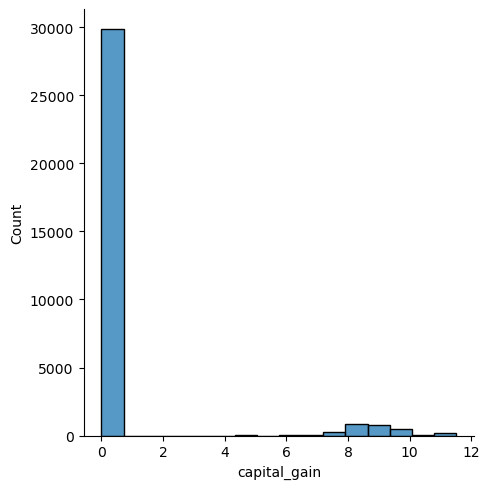

In [8]:
sns.displot(df['capital_gain'])

In [9]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,0.734601,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,2.454680,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,11.512915,4356.000000,99.000000


In [10]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
salary            0
dtype: int64

In [11]:
df['salary'].unique()

array([' <=50K', ' >50K'], dtype=object)

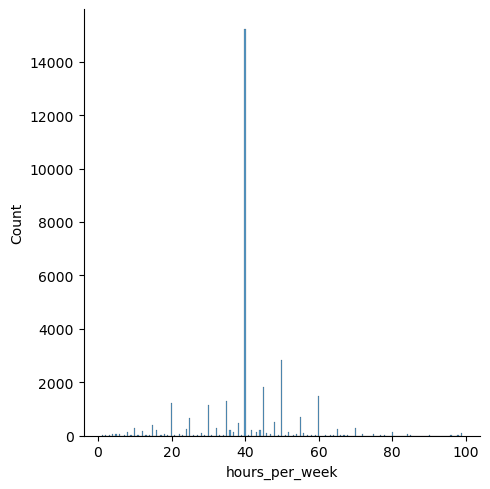

In [12]:
sns.displot(df['hours_per_week'])

<Axes: ylabel='hours_per_week'>

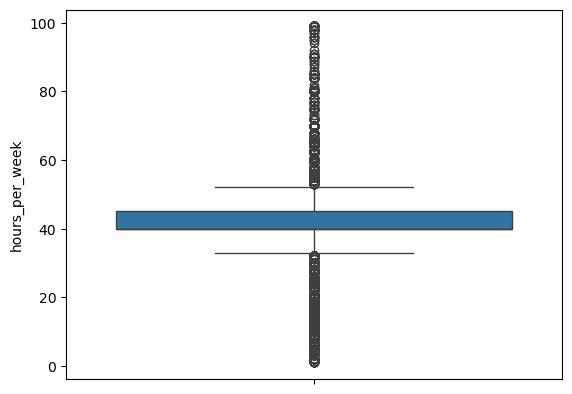

In [13]:
sns.boxplot(df['hours_per_week'])

In [14]:
def remove_outlier_hours_per_week(df):
    IQR = df['hours_per_week'].quantile(0.75) - df['hours_per_week'].quantile(0.25)

    lower_range = df['hours_per_week'].quantile(0.25) - (1.5 * IQR)
    upper_range = df['hours_per_week'].quantile(0.75) + (1.5 * IQR)

    df.loc[df['hours_per_week'] <= lower_range, 'hours_per_week'] = lower_range
    df.loc[df['hours_per_week'] >= upper_range, 'hours_per_week'] = upper_range


In [15]:
def remove_outlier_capital_loss(df):
    IQR = df['capital_loss'].quantile(0.75) - df['capital_loss'].quantile(0.25)

    lower_range = df['capital_loss'].quantile(0.25) - (1.5 * IQR)
    upper_range = df['capital_loss'].quantile(0.75) + (1.5 * IQR)

    df.loc[df['capital_loss'] <= lower_range, 'capital_loss'] = lower_range
    df.loc[df['capital_loss'] >= upper_range, 'capital_loss'] = upper_range


In [16]:
remove_outlier_capital_loss(df)


<Axes: ylabel='capital_loss'>

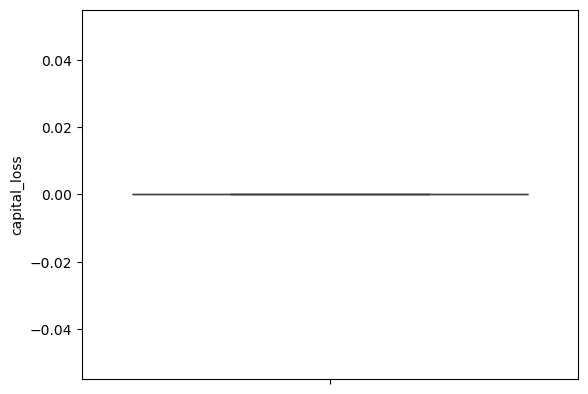

In [17]:
sns.boxplot(df['capital_loss'])


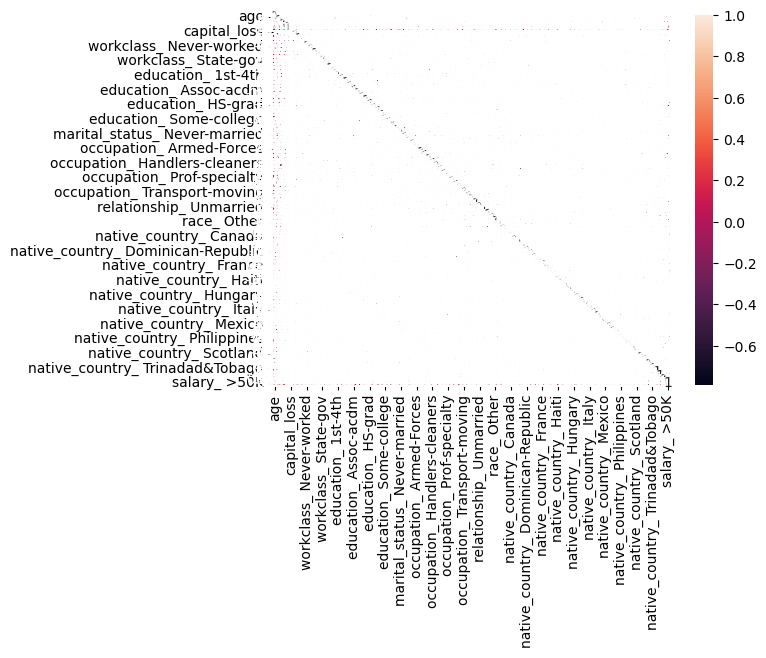

In [18]:
df_encoded = pd.get_dummies(df, drop_first=True)  # Converts categorical columns to numeric
corr = df_encoded.corr()  # Compute correlation on encoded DataFrame
sns.heatmap(corr, annot=True)
plt.show()


In [19]:
df = df.drop('fnlwgt', axis=1)


In [20]:
df.isnull().sum()


age               0
workclass         0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
salary            0
dtype: int64

In [21]:
df.head()


,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,salary
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,7.684324,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0,13,United-States,<=50K
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0,40,United-States,<=50K
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0,40,United-States,<=50K
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0,40,Cuba,<=50K


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [23]:
sc = StandardScaler()


In [24]:
X = df[['age', 'workclass', 'education', 'education_num', 'marital_status', 'occupation', 'relationship',
          'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country']]


In [25]:
y = df['salary']


In [26]:
y.value_counts()


salary
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [27]:
from sklearn.preprocessing import StandardScaler

# Convert categorical features to numeric
X_encoded = pd.get_dummies(X, drop_first=True)  # One-hot encoding

# Scale numerical data
sc = StandardScaler()
X_scaled = sc.fit_transform(X_encoded)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [29]:
print("Train data shape: {}".format(X_train.shape))
print("Test data shape: {}".format(X_test.shape))


Train data shape: (26048, 13)
Test data shape: (6513, 13)


In [30]:
from sklearn.linear_model import LogisticRegression


In [31]:
lg_model = LogisticRegression()


In [32]:
from sklearn.preprocessing import LabelEncoder

# Encode the target variable (salary)
le = LabelEncoder()
y = le.fit_transform(y)  # Convert categorical values to numbers

# Split the dataset again
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train the logistic regression model
lg_model.fit(X_train, y_train)


LogisticRegression()

In [33]:
y_pred = lg_model.predict(X_test)


In [34]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


In [35]:
print("Accuracy Score: {}".format(accuracy_score(y_test, y_pred)))
print("Confusion Matrix:\\n {}".format(confusion_matrix(y_test, y_pred)))
print("Classification Report:\\n {}".format(classification_report(y_test, y_pred)))


Accuracy Score: 0.8479963150621833
Confusion Matrix:\n [[4588  354]
 [ 636  935]]
Classification Report:\n               precision    recall  f1-score   support

           0       0.88      0.93      0.90      4942
           1       0.73      0.60      0.65      1571

    accuracy                           0.85      6513
   macro avg       0.80      0.76      0.78      6513
weighted avg       0.84      0.85      0.84      6513

